## Experiment Challenge: Credit Default Prediction

Dataset: *Default of Credit Card Clients* (UCI/Kaggle), 30.000 observasi.
Target: `default.payment.next.month` (0 = tidak default, 1 = default).

**Ketentuan utama:** train-test split sebelum training, tanpa data leakage (preprocessing di dalam `Pipeline`), 5-fold Stratified CV, metrik utama **F1-score** (pendukung: Accuracy, Precision, Recall).

**Alur:** Exp 0 (Data Understanding & Preparation) → Exp 1 (Baseline) → Exp 2 (Preprocessing) → Exp 3 (Model Comparison) → Exp 4 (Hyperparameter Tuning) → Exp 5 (Advanced Model) → Final Analysis.

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
TARGET = "default.payment.next.month"
PAY_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Saklar keputusan cleaning (sesuai keputusan analis).
# Ubah ke False untuk mempertahankan baris PAY bernilai -2 / 0.
HAPUS_PAY_NEG2_NOL = True

## Experiment 0 — Data Understanding & Preparation
### 0.1 Membaca dataset

In [ ]:
df_raw = pd.read_csv("/content/UCI_Credit_Card.csv")
df_raw.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### 0.2 Dimensi, struktur, dan tipe data

In [ ]:
print("Dimensi dataset (baris, kolom):", df_raw.shape)
print()
df_raw.info()

Dimensi dataset (baris, kolom): (30000, 25)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null 

In [ ]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


### 0.3 Variabel target, missing value, dan duplikat

In [ ]:
print("Variabel target :", TARGET)
print("Missing value total :", int(df_raw.isnull().sum().sum()))
print("Duplikat (semua kolom, termasuk ID)   :", int(df_raw.duplicated().sum()))
print("Duplikat (tanpa kolom ID)              :", int(df_raw.drop(columns="ID").duplicated().sum()))
print()
cnt = df_raw[TARGET].value_counts().sort_index()
print(pd.DataFrame({"jumlah": cnt, "persen": (cnt / len(df_raw) * 100).round(2)}))

Variabel target : default.payment.next.month
Missing value total : 0
Duplikat (semua kolom, termasuk ID)   : 0
Duplikat (tanpa kolom ID)              : 35

                            jumlah  persen
default.payment.next.month                
0                            23364   77.88
1                             6636   22.12


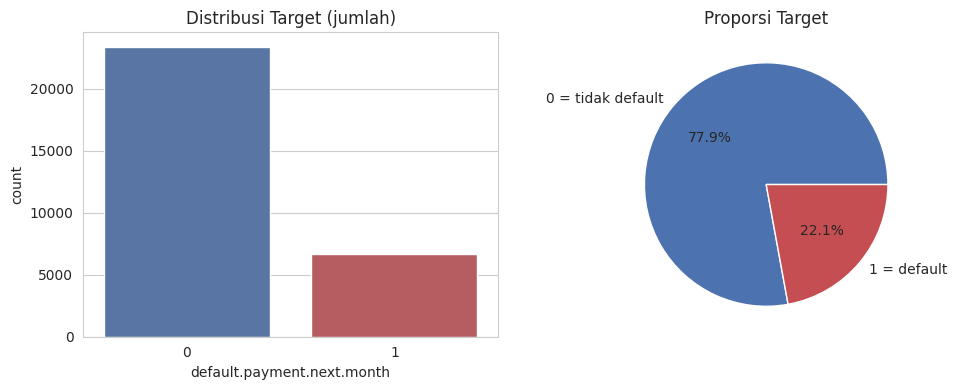

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=TARGET, data=df_raw, ax=ax[0], palette=["#4C72B0", "#C44E52"])
ax[0].set_title("Distribusi Target (jumlah)")
df_raw[TARGET].value_counts(normalize=True).sort_index().plot.pie(
    autopct="%.1f%%", ax=ax[1], colors=["#4C72B0", "#C44E52"], labels=["0 = tidak default", "1 = default"])
ax[1].set_ylabel(""); ax[1].set_title("Proporsi Target")
plt.tight_layout(); plt.show()

**Temuan:** tidak ada missing value; tidak ada duplikat bila `ID` ikut dihitung, tetapi ada beberapa baris dengan profil identik bila `ID` diabaikan. Target **tidak seimbang** (~78% : 22%), sehingga F1-score lebih tepat daripada Accuracy dan split perlu **stratified**.

### 0.4 Memeriksa nilai yang tidak sesuai / tidak wajar

In [ ]:
for c in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(c, df_raw[c].value_counts().sort_index().to_dict())
print()
for c in PAY_COLS:
    print(c, df_raw[c].value_counts().sort_index().to_dict())
print()
bill = [f"BILL_AMT{i}" for i in range(1, 7)]
print("Jumlah BILL_AMT negatif per kolom:", (df_raw[bill] < 0).sum().to_dict())

SEX {1: 11888, 2: 18112}
EDUCATION {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE {0: 54, 1: 13659, 2: 15964, 3: 323}

PAY_0 {-2: 2759, -1: 5686, 0: 14737, 1: 3688, 2: 2667, 3: 322, 4: 76, 5: 26, 6: 11, 7: 9, 8: 19}
PAY_2 {-2: 3782, -1: 6050, 0: 15730, 1: 28, 2: 3927, 3: 326, 4: 99, 5: 25, 6: 12, 7: 20, 8: 1}
PAY_3 {-2: 4085, -1: 5938, 0: 15764, 1: 4, 2: 3819, 3: 240, 4: 76, 5: 21, 6: 23, 7: 27, 8: 3}
PAY_4 {-2: 4348, -1: 5687, 0: 16455, 1: 2, 2: 3159, 3: 180, 4: 69, 5: 35, 6: 5, 7: 58, 8: 2}
PAY_5 {-2: 4546, -1: 5539, 0: 16947, 2: 2626, 3: 178, 4: 84, 5: 17, 6: 4, 7: 58, 8: 1}
PAY_6 {-2: 4895, -1: 5740, 0: 16286, 2: 2766, 3: 184, 4: 49, 5: 13, 6: 19, 7: 46, 8: 2}

Jumlah BILL_AMT negatif per kolom: {'BILL_AMT1': 590, 'BILL_AMT2': 669, 'BILL_AMT3': 655, 'BILL_AMT4': 675, 'BILL_AMT5': 655, 'BILL_AMT6': 688}


**Temuan dan keputusan cleaning:**
- `EDUCATION`: dokumentasi hanya mendefinisikan 1–4 (4 = others), tetapi data berisi 0, 5, dan 6. Nilai **5 dan 6 (unknown) digabung menjadi satu kategori (5)** dan **tidak digabung dengan 4**. Nilai 0 yang tidak terdokumentasi diperlakukan sebagai *unknown* juga (masuk kategori 5).
- `MARRIAGE`: nilai **0** tidak terdokumentasi, digabungkan dengan 3 (others)
- `PAY_0`–`PAY_6`: nilai **-2** dan **0** tidak terdokumentasi → baris yang mengandung nilai tersebut dugabungkan dengan -1 (pay duly)
- `BILL_AMT` negatif dipertahankan (dapat berarti kelebihan bayar, bukan kesalahan data).
- Kolom `ID` dikeluarkan dari predictor.

In [ ]:
TARGET = "default.payment.next.month"
PAY_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

df = df_raw.drop(columns="ID").copy()          # ID bukan predictor
log = [("Data awal", len(df))]

# EDUCATION: 0, 5, 6 -> 5 (unknown), tetap terpisah dari 4 (others)
df["EDUCATION"] = df["EDUCATION"].replace({0: 5, 6: 5})
log.append(("Setelah merapikan EDUCATION (tanpa hapus baris)", len(df)))

# MARRIAGE: 0 digabung ke 3 (others), tanpa hapus baris
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})
log.append(("Setelah menggabungkan MARRIAGE 0 ke 3 (tanpa hapus baris)", len(df)))

# PAY_*: -2 dan 0 digabung ke -1 (bayar tepat waktu), tanpa hapus baris
for c in PAY_COLS:
    df[c] = df[c].map(lambda v: -1 if v in (-2, 0) else v)
log.append(("Setelah menggabungkan PAY_* -2 dan 0 ke -1 (tanpa hapus baris)", len(df)))

df = df.reset_index(drop=True)

log_df = pd.DataFrame(log, columns=["Tahap", "Jumlah baris"])
log_df["Dibuang"] = log_df["Jumlah baris"].shift(1, fill_value=len(df_raw)) - log_df["Jumlah baris"]
display(log_df)

print("\nNilai EDUCATION  :", df["EDUCATION"].value_counts().sort_index().to_dict())
print("Nilai MARRIAGE   :", df["MARRIAGE"].value_counts().sort_index().to_dict())
for c in PAY_COLS:
    print(f"Nilai {c:<6}:", df[c].value_counts().sort_index().to_dict())
print("\nDuplikat setelah cleaning:", int(df.duplicated().sum()), "(dipertahankan: tanpa ID tidak ada kunci unik, bisa jadi nasabah berbeda)")
print("Proporsi default setelah cleaning:", df[TARGET].value_counts(normalize=True).round(4).to_dict())

# Verifikasi
assert len(df) == len(df_raw), "Jumlah baris berubah, seharusnya tidak ada baris yang dihapus"
assert not df[PAY_COLS].isin([-2, 0]).any().any(), "Masih ada -2/0 pada PAY_*"
assert df["MARRIAGE"].isin([1, 2, 3]).all(), "MARRIAGE harus hanya berisi 1, 2, 3"
print("\nOK: 30.000 baris utuh; PAY_* hanya berisi -1 dan 1 sampai 8; MARRIAGE hanya berisi 1, 2, 3.")

,Tahap,Jumlah baris,Dibuang
0,Data awal,30000,0
1,Setelah merapikan EDUCATION (tanpa hapus baris),30000,0
2,Setelah menggabungkan MARRIAGE 0 ke 3 (tanpa h...,30000,0
3,Setelah menggabungkan PAY_* -2 dan 0 ke -1 (ta...,30000,0



Nilai EDUCATION  : {1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 345}
Nilai MARRIAGE   : {1: 13659, 2: 15964, 3: 377}
Nilai PAY_0 : {-1: 23182, 1: 3688, 2: 2667, 3: 322, 4: 76, 5: 26, 6: 11, 7: 9, 8: 19}
Nilai PAY_2 : {-1: 25562, 1: 28, 2: 3927, 3: 326, 4: 99, 5: 25, 6: 12, 7: 20, 8: 1}
Nilai PAY_3 : {-1: 25787, 1: 4, 2: 3819, 3: 240, 4: 76, 5: 21, 6: 23, 7: 27, 8: 3}
Nilai PAY_4 : {-1: 26490, 1: 2, 2: 3159, 3: 180, 4: 69, 5: 35, 6: 5, 7: 58, 8: 2}
Nilai PAY_5 : {-1: 27032, 2: 2626, 3: 178, 4: 84, 5: 17, 6: 4, 7: 58, 8: 1}
Nilai PAY_6 : {-1: 26921, 2: 2766, 3: 184, 4: 49, 5: 13, 6: 19, 7: 46, 8: 2}

Duplikat setelah cleaning: 36 (dipertahankan: tanpa ID tidak ada kunci unik, bisa jadi nasabah berbeda)
Proporsi default setelah cleaning: {0: 0.7788, 1: 0.2212}

OK: 30.000 baris utuh; PAY_* hanya berisi -1 dan 1 sampai 8; MARRIAGE hanya berisi 1, 2, 3.


,Q1 (25%),Q3 (75%),IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase Outlier (%)
Variabel,,,,,,,
PAY_0,-1.00,-1.00,0.00,-1.000,-1.000,6818,22.73
PAY_2,-1.00,-1.00,0.00,-1.000,-1.000,4438,14.79
PAY_3,-1.00,-1.00,0.00,-1.000,-1.000,4213,14.04
PAY_4,-1.00,-1.00,0.00,-1.000,-1.000,3510,11.70
PAY_6,-1.00,-1.00,0.00,-1.000,-1.000,3079,10.26
PAY_AMT4,296.00,4013.25,3717.25,-5279.875,9589.125,2994,9.98
PAY_5,-1.00,-1.00,0.00,-1.000,-1.000,2968,9.89
PAY_AMT6,117.75,4000.00,3882.25,-5705.625,9823.375,2958,9.86
PAY_AMT5,252.50,4031.50,3779.00,-5416.000,9700.000,2945,9.82


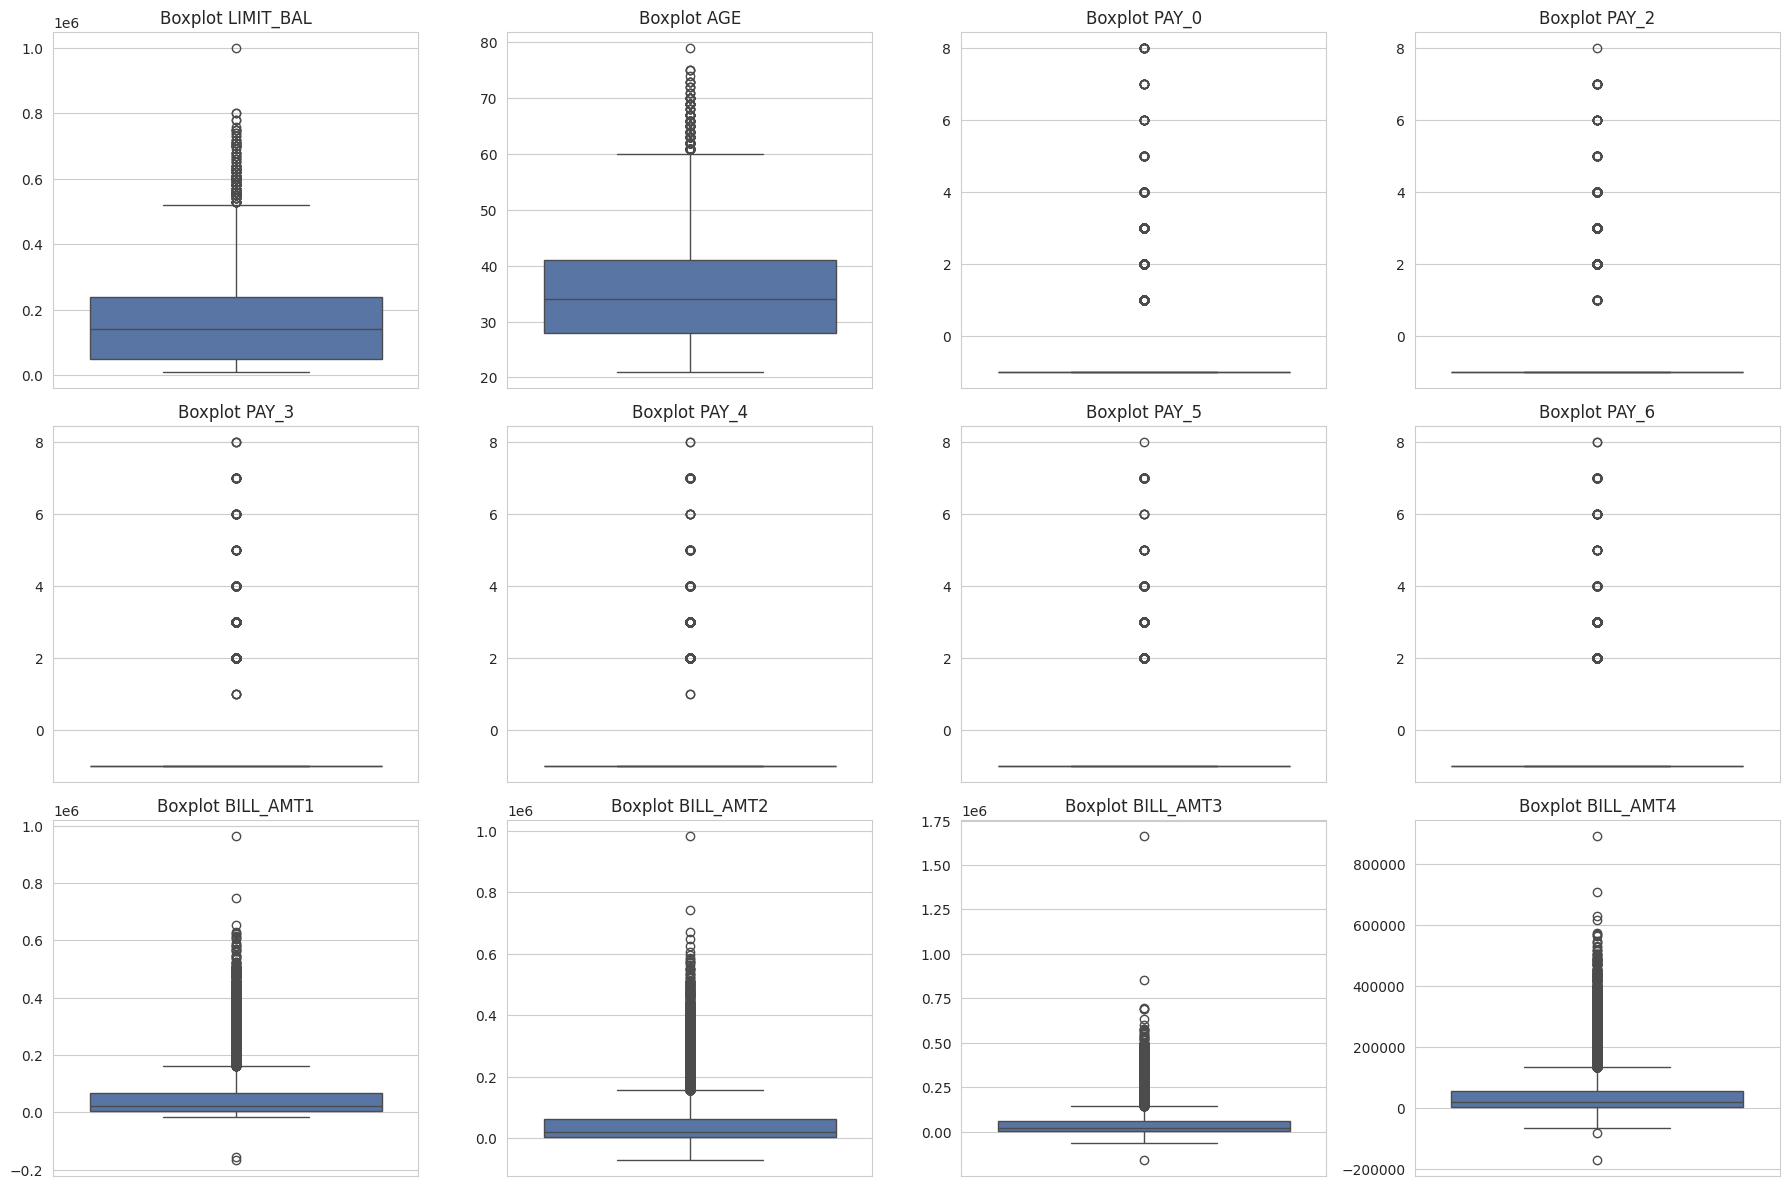

In [ ]:
# Identifikasi kolom numerik (kecuali target dan fitur kategorikal yang di-encode angka)
num_cols_to_check = [c for c in df.columns if c not in [TARGET, 'SEX', 'EDUCATION', 'MARRIAGE']]

outlier_summary = []

for col in num_cols_to_check:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Hitung outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)
    pct_outliers = (num_outliers / len(df)) * 100

    outlier_summary.append({
        "Variabel": col,
        "Q1 (25%)": q1,
        "Q3 (75%)": q3,
        "IQR": iqr,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Jumlah Outlier": num_outliers,
        "Persentase Outlier (%)": round(pct_outliers, 2)
    })

# Tampilkan tabel ringkasan outlier
df_outliers = pd.DataFrame(outlier_summary).set_index("Variabel")
display(df_outliers.sort_values(by="Jumlah Outlier", ascending=False))

# Visualisasi boxplot untuk variabel dengan outlier terbanyak
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(num_cols_to_check[:12]): # Menampilkan 12 variabel numerik pertama
    sns.boxplot(y=df[col], ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Boxplot {col}")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

Outlier tidak dihapus karena jumlahnya signifikan dan bisa berarti memang demikian adanya (bukan kesalahan input atau lainnya)

### 0.5 Visualisasi eksplorasi (data setelah cleaning)

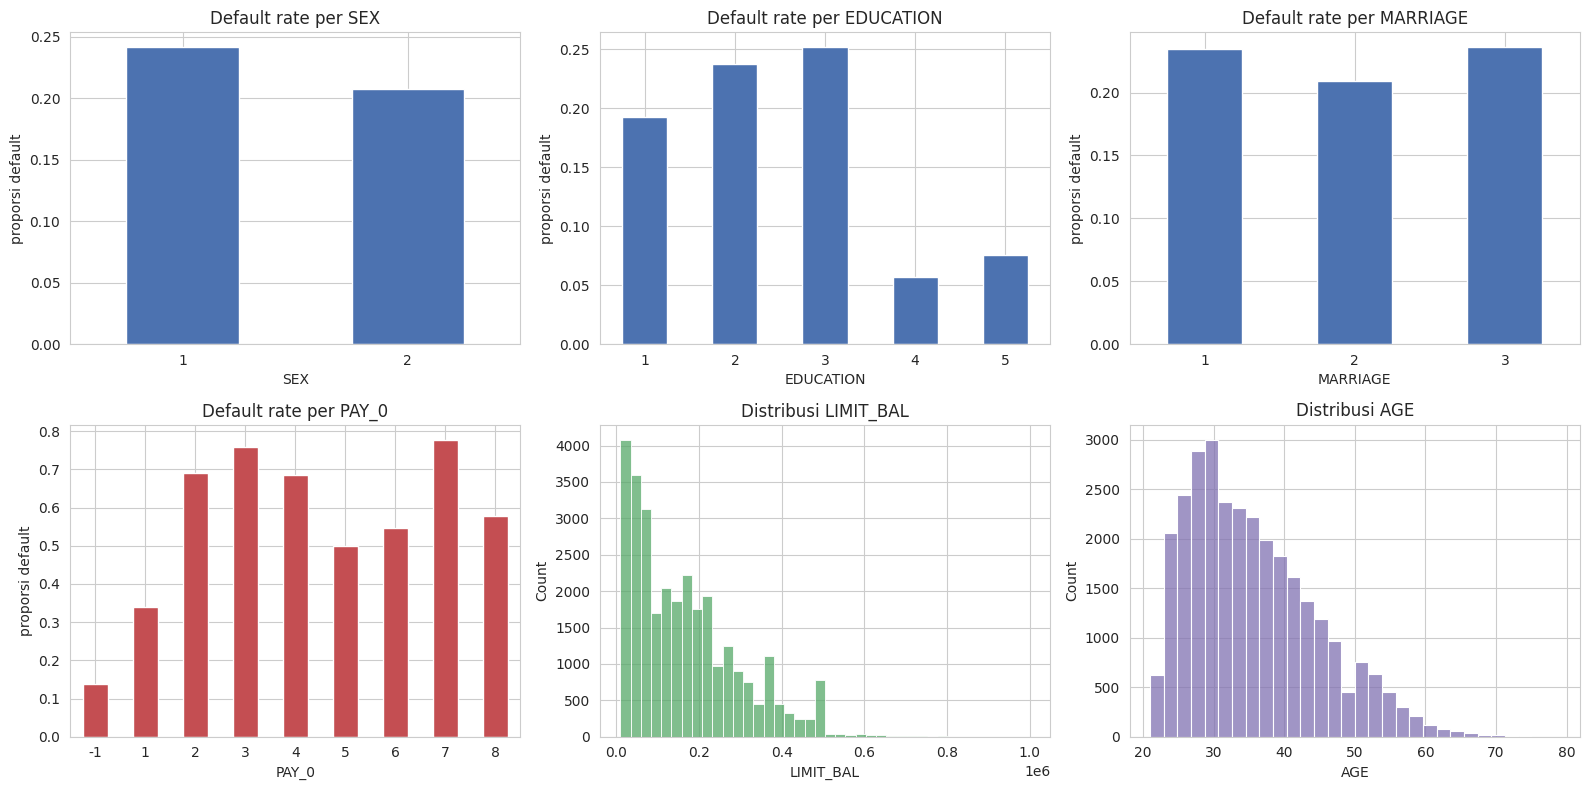

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel()[:3], ["SEX", "EDUCATION", "MARRIAGE"]):
    df.groupby(c)[TARGET].mean().plot.bar(ax=ax, color="#4C72B0", rot=0)
    ax.set_title(f"Default rate per {c}"); ax.set_ylabel("proporsi default")
df.groupby("PAY_0")[TARGET].mean().plot.bar(ax=axes[1, 0], color="#C44E52", rot=0)
axes[1, 0].set_title("Default rate per PAY_0"); axes[1, 0].set_ylabel("proporsi default")
sns.histplot(df["LIMIT_BAL"], bins=40, ax=axes[1, 1], color="#55A868"); axes[1, 1].set_title("Distribusi LIMIT_BAL")
sns.histplot(df["AGE"], bins=30, ax=axes[1, 2], color="#8172B2"); axes[1, 2].set_title("Distribusi AGE")
plt.tight_layout(); plt.show()

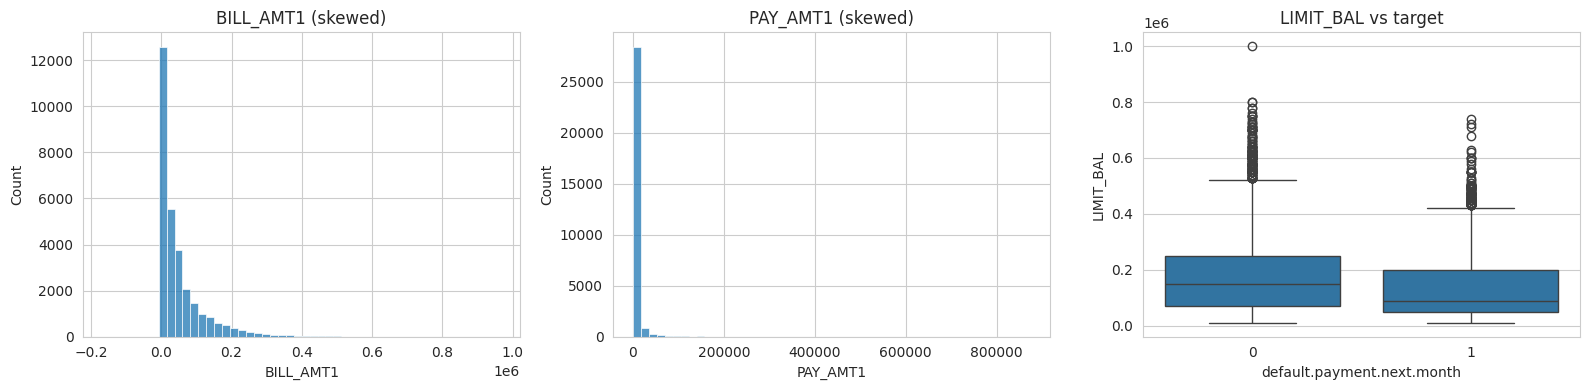

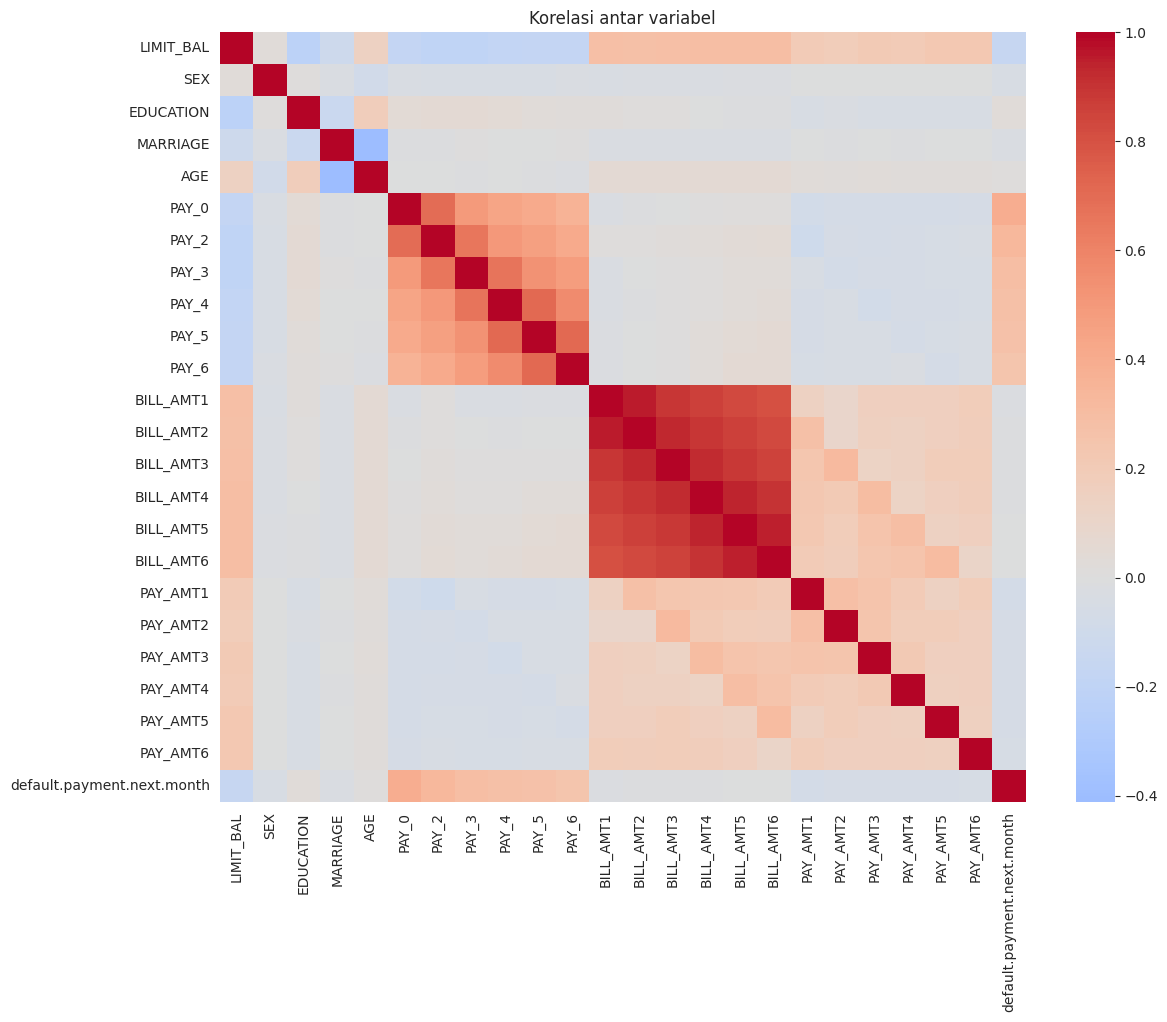

PAY_0        0.399
PAY_2        0.333
PAY_3        0.292
PAY_4        0.275
PAY_5        0.266
PAY_6        0.248
EDUCATION    0.027
AGE          0.014
Name: default.payment.next.month, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["BILL_AMT1"], bins=50, ax=axes[0]); axes[0].set_title("BILL_AMT1 (skewed)")
sns.histplot(df["PAY_AMT1"], bins=50, ax=axes[1]); axes[1].set_title("PAY_AMT1 (skewed)")
sns.boxplot(x=TARGET, y="LIMIT_BAL", data=df, ax=axes[2]); axes[2].set_title("LIMIT_BAL vs target")
plt.tight_layout(); plt.show()

plt.figure(figsize=(13, 10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Korelasi antar variabel"); plt.show()
print(df.corr()[TARGET].drop(TARGET).sort_values(ascending=False).round(3).head(8))

**Catatan:** variabel `PAY_*` memiliki hubungan terkuat dengan target. Variabel jumlah uang (`LIMIT_BAL`, `BILL_AMT`, `PAY_AMT`) sangat skewed dengan skala jauh berbeda dari variabel lain → relevan untuk *feature scaling* pada Experiment 2.

### 0.6 Menentukan predictor & target, serta train-test split
Split dilakukan **sebelum** training/fitting transformer apa pun (80% train, 20% test, `stratify=y`). Seluruh preprocessing yang menggunakan statistik data (scaling, encoding) dimasukkan ke `Pipeline` sehingga hanya di-*fit* pada data training (termasuk di dalam tiap fold CV) → **tidak ada data leakage**. Cleaning di 0.4 bersifat aturan tetap (bukan statistik data), sehingga aman dilakukan sebelum split.

In [ ]:
X = df.drop(columns=TARGET)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Proporsi default train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))
print("Predictor:", list(X.columns))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols = [c for c in X.columns if c not in cat_cols]

def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ])

X_train: (24000, 23) | X_test: (6000, 23)
Proporsi default train: 0.2212 | test: 0.2212
Predictor: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


### Fungsi evaluasi (dipakai seluruh eksperimen)
Prosedur sama untuk setiap model: 5-fold Stratified CV (F1) pada training set → fit pada seluruh training set → evaluasi pada test set (Accuracy, Precision, Recall, F1).

In [ ]:
results = []      # seluruh hasil eksperimen
fitted = {}       # model terlatih, untuk analisis akhir

COMPLEXITY = {"Logistic Regression": 1, "Decision Tree": 2, "Random Forest": 3,
              "Gradient Boosting": 4, "XGBoost": 4}

def evaluate(label, exp, model_name, model):
    cv = cross_validate(model, X_train, y_train, cv=skf, scoring="f1", n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    row = {"Label": label, "Experiment": exp, "Model": model_name,
           "CV F1": cv["test_score"].mean(), "CV Std": cv["test_score"].std(),
           "Test Accuracy": accuracy_score(y_test, pred),
           "Test Precision": precision_score(y_test, pred, zero_division=0),
           "Test Recall": recall_score(y_test, pred),
           "Test F1": f1_score(y_test, pred),
           "Kompleksitas": COMPLEXITY[model_name]}
    results.append(row)
    fitted[label] = model
    return row

METRICS = ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]
def R():
    return pd.DataFrame(results).set_index("Label")

## Experiment 1 — Baseline Model
Logistic Regression **tanpa** scaling dan encoding (fitur mentah hasil cleaning) sebagai pembanding.

In [ ]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
evaluate("Exp1 LR Baseline", 1, "Logistic Regression", baseline)
R().loc[["Exp1 LR Baseline"], ["CV F1", "CV Std"] + METRICS[1:]].round(4)

,CV F1,CV Std,Test Accuracy,Test Precision,Test Recall,Test F1
Label,,,,,,
Exp1 LR Baseline,0.4197,0.0326,0.8083,0.6188,0.3474,0.445


## Experiment 2 — Preprocessing
Preprocessing yang diterapkan, beserta alasannya:
- **StandardScaler** pada variabel numerik: skala `LIMIT_BAL`, `BILL_AMT`, `PAY_AMT` jauh lebih besar dari variabel lain, sedangkan Logistic Regression sensitif terhadap skala.
- **OneHotEncoder** pada `SEX`, `EDUCATION`, `MARRIAGE`: ketiganya nominal, sehingga kode angkanya tidak boleh dianggap berurutan.
- `PAY_*` dibiarkan numerik karena bersifat ordinal (tingkat keterlambatan).

Selain model lengkap (scaling + encoding), dilakukan ablasi untuk melihat kontribusi masing-masing langkah.

,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Label,,,,,
Exp1 LR Baseline,0.4197,0.8083,0.6188,0.3474,0.4450
Exp2a LR + Scaling saja,0.4490,0.8120,0.6519,0.3218,0.4309
Exp2 LR + Preprocessing,0.4487,0.8123,0.6507,0.3271,0.4353


,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Selisih Exp2 - Exp1,0.029,0.004,0.0319,-0.0203,-0.0097


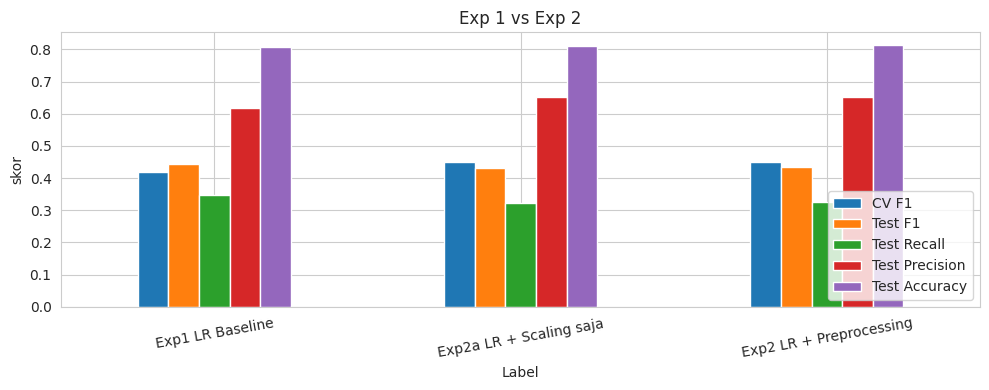

In [ ]:
# Ablasi: hanya scaling (kategori dibiarkan numerik)
prep_scale_only = ColumnTransformer([("num", StandardScaler(), num_cols + cat_cols)])
evaluate("Exp2a LR + Scaling saja", "2a", "Logistic Regression",
         Pipeline([("prep", prep_scale_only), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]))

# Model Exp 2 final: scaling + encoding
evaluate("Exp2 LR + Preprocessing", 2, "Logistic Regression",
         Pipeline([("prep", make_preprocessor()), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]))

comp2 = R().loc[["Exp1 LR Baseline", "Exp2a LR + Scaling saja", "Exp2 LR + Preprocessing"], ["CV F1"] + METRICS[1:]]
display(comp2.round(4))

delta2 = (comp2.loc["Exp2 LR + Preprocessing"] - comp2.loc["Exp1 LR Baseline"]).to_frame("Selisih Exp2 - Exp1").T
display(delta2.round(4))

comp2[["CV F1", "Test F1", "Test Recall", "Test Precision", "Test Accuracy"]].plot.bar(figsize=(10, 4), rot=10)
plt.title("Exp 1 vs Exp 2"); plt.ylabel("skor"); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [ ]:
def arah(d, eps=0.0005):
    return "meningkat" if d > eps else ("menurun" if d < -eps else "relatif tidak berubah")

b, p = R().loc["Exp1 LR Baseline"], R().loc["Exp2 LR + Preprocessing"]
print(f"CV F1   : {b['CV F1']:.4f} -> {p['CV F1']:.4f} ({arah(p['CV F1']-b['CV F1'])})")
print(f"Test F1 : {b['Test F1']:.4f} -> {p['Test F1']:.4f} ({arah(p['Test F1']-b['Test F1'])})")
print(f"Accuracy {arah(p['Test Accuracy']-b['Test Accuracy'])}, Precision {arah(p['Test Precision']-b['Test Precision'])}, Recall {arah(p['Test Recall']-b['Test Recall'])}")
improved = (p["CV F1"] - b["CV F1"] > 0.0005) and (p["Test F1"] - b["Test F1"] > 0.0005)
print("\nKesimpulan Exp 2:", "preprocessing MEMBERI peningkatan performa (CV F1 dan Test F1 sama-sama naik)."
      if improved else "preprocessing TIDAK memberi peningkatan yang konsisten pada CV F1 dan Test F1.")

CV F1   : 0.4197 -> 0.4487 (meningkat)
Test F1 : 0.4450 -> 0.4353 (menurun)
Accuracy meningkat, Precision meningkat, Recall menurun

Kesimpulan Exp 2: preprocessing TIDAK memberi peningkatan yang konsisten pada CV F1 dan Test F1.


## Experiment 3 — Model Comparison
Logistic Regression, Decision Tree, dan Random Forest dievaluasi dengan prosedur dan preprocessor yang sama (pipeline dari Exp 2). Parameter masih default/standar. **Model terbaik dipilih otomatis berdasarkan CV F1** (metrik utama, dihitung hanya dari training set); test set dipakai sebagai konfirmasi.

,CV F1,CV Std,Test Accuracy,Test Precision,Test Recall,Test F1
Model,,,,,,
Logistic Regression,0.4487,0.0099,0.8123,0.6507,0.3271,0.4353
Decision Tree,0.3998,0.0124,0.7220,0.3785,0.4002,0.3890
Random Forest,0.4762,0.0057,0.8142,0.6380,0.3693,0.4678


Model terbaik Exp 3 (CV F1 tertinggi): Random Forest  |  CV F1 = 0.4762, Test F1 = 0.4678
Model dengan Test F1 tertinggi        : Random Forest


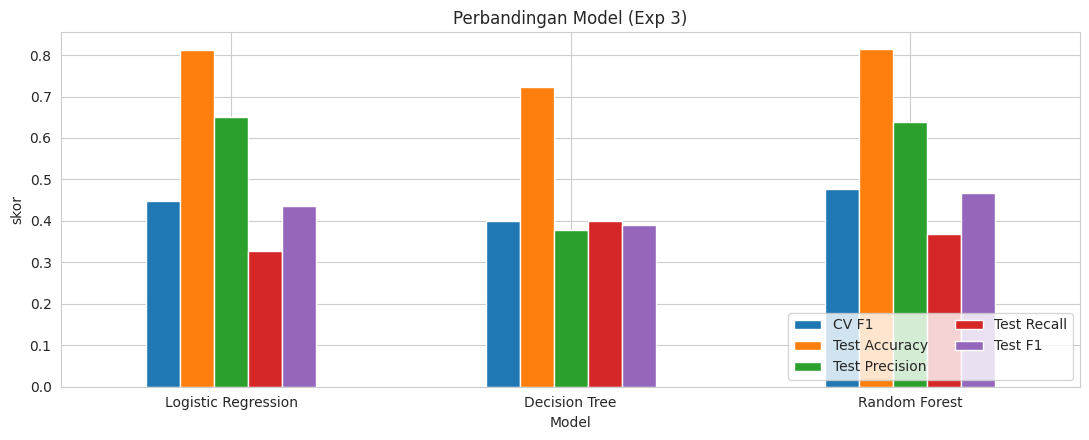

In [ ]:
def make_model(name):
    if name == "Logistic Regression":
        clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    elif name == "Decision Tree":
        clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
    elif name == "Random Forest":
        clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1)
    return Pipeline([("prep", make_preprocessor()), ("clf", clf)])

for name in ["Logistic Regression", "Decision Tree", "Random Forest"]:
    evaluate(f"Exp3 {name}", 3, name, make_model(name))

exp3 = R()[R()["Experiment"] == 3][["Model", "CV F1", "CV Std"] + METRICS[1:]].set_index("Model")
display(exp3.round(4))

best3 = exp3["CV F1"].idxmax()
print(f"Model terbaik Exp 3 (CV F1 tertinggi): {best3}  |  CV F1 = {exp3.loc[best3, 'CV F1']:.4f}, Test F1 = {exp3.loc[best3, 'Test F1']:.4f}")
print("Model dengan Test F1 tertinggi        :", exp3["Test F1"].idxmax())

exp3[METRICS].plot.bar(figsize=(11, 4.5), rot=0)
plt.title("Perbandingan Model (Exp 3)"); plt.ylabel("skor"); plt.legend(loc="lower right", ncol=2); plt.tight_layout(); plt.show()

## Experiment 4 — Hyperparameter Tuning
Model terbaik dari Exp 3 dituning dengan `GridSearchCV` (5-fold Stratified CV, `scoring="f1"`). Grid disesuaikan dengan model terpilih.

In [ ]:
GRIDS = {
    "Logistic Regression": {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
                            "clf__class_weight": [None, "balanced"]},
    "Decision Tree": {"clf__max_depth": [3, 5, 7, 10, None],
                      "clf__min_samples_leaf": [1, 5, 10, 20],
                      "clf__criterion": ["gini", "entropy"],
                      "clf__class_weight": [None, "balanced"]},
    "Random Forest": {"clf__n_estimators": [100, 300],
                      "clf__max_depth": [5, 10, None],
                      "clf__min_samples_leaf": [1, 3, 5],
                      "clf__class_weight": [None, "balanced"]},
}
grid = GRIDS[best3]
print("Model yang dituning :", best3)
print("Hyperparameter diuji:")
for k, v in grid.items():
    print(f"  {k.replace('clf__', '')}: {v}")
n_comb = int(np.prod([len(v) for v in grid.values()]))
print(f"Total kombinasi: {n_comb} x 5 fold = {n_comb * 5} fit")

Model yang dituning : Random Forest
Hyperparameter diuji:
  n_estimators: [100, 300]
  max_depth: [5, 10, None]
  min_samples_leaf: [1, 3, 5]
  class_weight: [None, 'balanced']
Total kombinasi: 36 x 5 fold = 180 fit


In [ ]:
gs = GridSearchCV(make_model(best3), param_grid=grid, scoring="f1", cv=skf, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

print("Kombinasi terbaik:", {k.replace("clf__", ""): v for k, v in gs.best_params_.items()})
print(f"Best CV F1       : {gs.best_score_:.4f}")

tuned_label = f"Exp4 Tuned {best3}"
tuned_row = evaluate(tuned_label, 4, best3, gs.best_estimator_)
fitted[tuned_label] = gs.best_estimator_

top = pd.DataFrame(gs.cv_results_).sort_values("rank_test_score").head(5)
display(top[["rank_test_score", "mean_test_score", "std_test_score", "params"]])

Kombinasi terbaik: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 300}
Best CV F1       : 0.5419


,rank_test_score,mean_test_score,std_test_score,params
27,1,0.541898,0.004839,"{'clf__class_weight': 'balanced', 'clf__max_de..."
29,2,0.541453,0.005073,"{'clf__class_weight': 'balanced', 'clf__max_de..."
26,3,0.541436,0.006192,"{'clf__class_weight': 'balanced', 'clf__max_de..."
28,4,0.541385,0.004428,"{'clf__class_weight': 'balanced', 'clf__max_de..."
22,5,0.540224,0.008108,"{'clf__class_weight': 'balanced', 'clf__max_de..."


,Sebelum tuning,Sesudah tuning,Selisih
CV F1,0.476197,0.541898,0.065701
Test Accuracy,0.814167,0.7865,-0.027667
Test Precision,0.638021,0.515862,-0.122159
Test Recall,0.369254,0.563677,0.194424
Test F1,0.46778,0.538711,0.07093


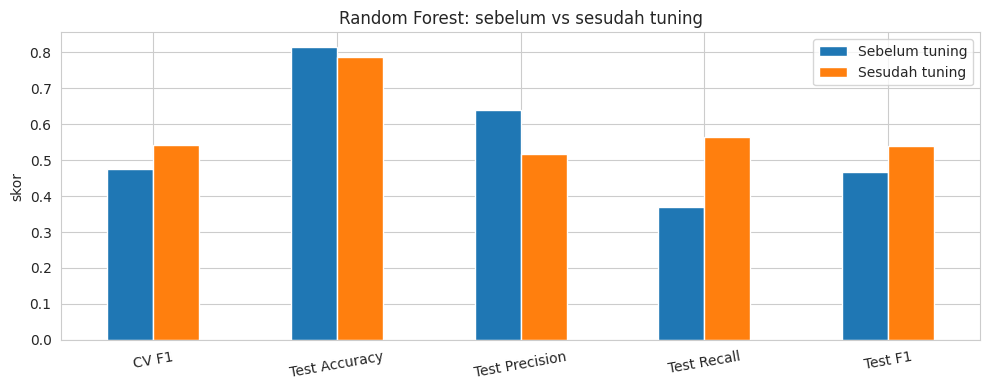

CV F1   meningkat (0.4762 -> 0.5419)
Test F1 meningkat (0.4678 -> 0.5387)


In [ ]:
before = R().loc[f"Exp3 {best3}", ["CV F1"] + METRICS[1:]]
after = R().loc[tuned_label, ["CV F1"] + METRICS[1:]]
cmp4 = pd.DataFrame({"Sebelum tuning": before, "Sesudah tuning": after})
cmp4["Selisih"] = cmp4["Sesudah tuning"] - cmp4["Sebelum tuning"]
display(cmp4.round(4))

cmp4[["Sebelum tuning", "Sesudah tuning"]].plot.bar(figsize=(10, 4), rot=10)
plt.title(f"{best3}: sebelum vs sesudah tuning"); plt.ylabel("skor"); plt.tight_layout(); plt.show()

print(f"CV F1   {arah(cmp4.loc['CV F1', 'Selisih'])} ({before['CV F1']:.4f} -> {after['CV F1']:.4f})")
print(f"Test F1 {arah(cmp4.loc['Test F1', 'Selisih'])} ({before['Test F1']:.4f} -> {after['Test F1']:.4f})")

## Experiment 5 — Advanced Model
Empat metode boosting dievaluasi dengan prosedur yang sama: **XGBoost**, **Gradient Boosting**, **AdaBoost**, dan **Stacking**. Model advanced yang dilaporkan pada tabel akhir adalah yang CV F1-nya tertinggi. Hasilnya dibandingkan dengan model terbaik Exp 4.

Melatih & mengevaluasi: XGBoost ...
Melatih & mengevaluasi: Gradient Boosting ...
Melatih & mengevaluasi: AdaBoost ...
Melatih & mengevaluasi: Stacking ...


,CV F1,CV Std,Test Accuracy,Test Precision,Test Recall,Test F1
Model,,,,,,
XGBoost,0.4780,0.0073,0.8182,0.6621,0.3632,0.4691
Stacking,0.4780,0.0093,0.8180,0.6621,0.3617,0.4678
Gradient Boosting,0.4774,0.0070,0.8190,0.6662,0.3640,0.4708
AdaBoost,0.4545,0.0109,0.8160,0.6692,0.3323,0.4441



Model advanced terbaik (CV F1 tertinggi): XGBoost
Model advanced terbaik (Test F1 tertinggi): Gradient Boosting


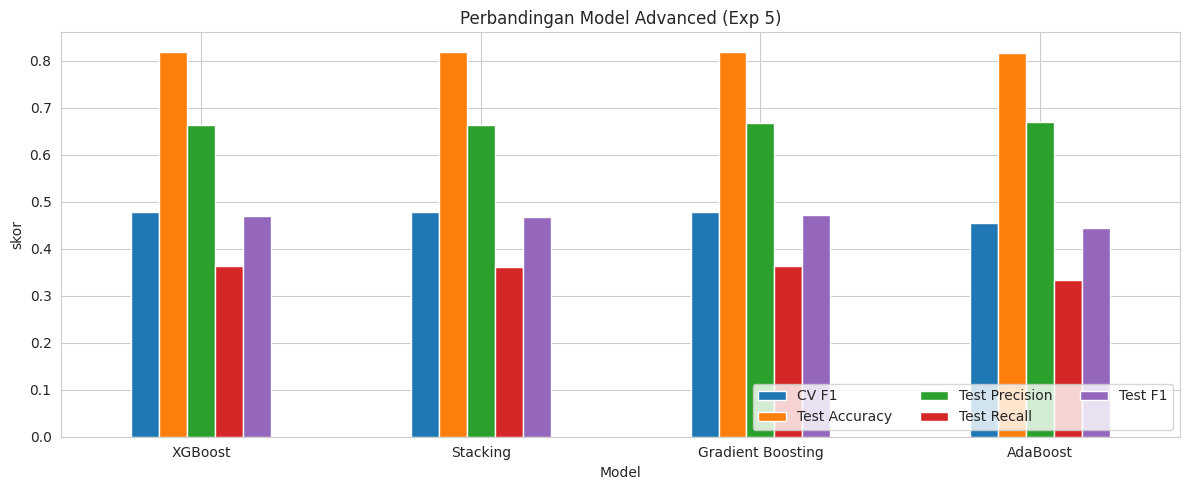

,Exp4 Tuned Random Forest,Exp5 XGBoost,Selisih (Exp5 - Exp4)
CV F1,0.541898,0.478025,-0.063874
Test Accuracy,0.7865,0.818167,0.031667
Test Precision,0.515862,0.662088,0.146226
Test Recall,0.563677,0.363225,-0.200452
Test F1,0.538711,0.4691,-0.069611


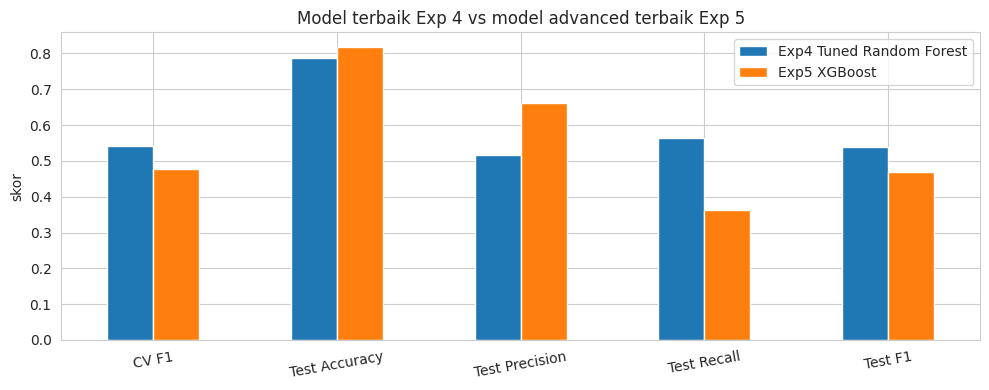

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, StackingClassifier

# Daftarkan kompleksitas model baru (dipakai aturan pemilihan model final)
COMPLEXITY.update({"AdaBoost": 4, "Stacking": 5})

def make_advanced(name):
    if name == "XGBoost":
        clf = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8,
                            colsample_bytree=0.8, eval_metric="logloss",
                            random_state=RANDOM_STATE, n_jobs=1)
    elif name == "Gradient Boosting":
        clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                         random_state=RANDOM_STATE)
    elif name == "AdaBoost":
        clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
                                 n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE)
    elif name == "Stacking":
        base = [
            ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
            ("rf", RandomForestClassifier(n_estimators=100, min_samples_leaf=3,
                                          random_state=RANDOM_STATE, n_jobs=1)),
            ("gb", GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3,
                                              random_state=RANDOM_STATE)),
        ]
        clf = StackingClassifier(estimators=base,
                                 final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                                 cv=5, stack_method="predict_proba", n_jobs=1)
    return Pipeline([("prep", make_preprocessor()), ("clf", clf)])

ADV_MODELS = ["XGBoost", "Gradient Boosting", "AdaBoost", "Stacking"]

for name in ADV_MODELS:
    print(f"Melatih & mengevaluasi: {name} ...")
    evaluate(f"Exp5 {name}", 5, name, make_advanced(name))

# Tabel perbandingan seluruh model advanced
exp5 = R()[R()["Experiment"] == 5][["Model", "CV F1", "CV Std"] + METRICS[1:]].set_index("Model")
exp5 = exp5.sort_values("CV F1", ascending=False)
display(exp5.round(4))

# Pemilihan model advanced terbaik berdasarkan CV F1 (test set hanya konfirmasi)
best5 = exp5["CV F1"].idxmax()
print(f"\nModel advanced terbaik (CV F1 tertinggi): {best5}")
print(f"Model advanced terbaik (Test F1 tertinggi): {exp5['Test F1'].idxmax()}")

# Visualisasi perbandingan model advanced
exp5[METRICS].plot.bar(figsize=(12, 5), rot=0)
plt.title("Perbandingan Model Advanced (Exp 5)")
plt.ylabel("skor"); plt.legend(loc="lower right", ncol=3)
plt.tight_layout(); plt.show()

# Perbandingan model advanced terbaik vs model terbaik Exp 4
cmp5 = pd.DataFrame({
    f"Exp4 Tuned {best3}": R().loc[tuned_label, ["CV F1"] + METRICS[1:]],
    f"Exp5 {best5}": R().loc[f"Exp5 {best5}", ["CV F1"] + METRICS[1:]],
})
cmp5["Selisih (Exp5 - Exp4)"] = cmp5.iloc[:, 1] - cmp5.iloc[:, 0]
display(cmp5.round(4))

cmp5.iloc[:, :2].plot.bar(figsize=(10, 4), rot=10)
plt.title("Model terbaik Exp 4 vs model advanced terbaik Exp 5")
plt.ylabel("skor"); plt.tight_layout(); plt.show()


### Ringkasan Hasil Eksperimen

In [ ]:
res = R()
summary = res[res["Experiment"].isin([1, 2, 3, 4]) | (res.index == f"Exp5 {best5}")].copy()
summary["Experiment"] = summary["Experiment"].astype(str)
summary = summary[["Experiment", "Model"] + METRICS]
summary = summary.rename(columns={"CV F1": "CV F1", "Test Accuracy": "Test Accuracy"})
desc = {"1": "Baseline", "2": "Baseline + Preprocessing", "3": "Model Comparison", "4": "Tuned Model", "5": "Advanced Model"}
summary.insert(1, "Keterangan", summary["Experiment"].map(desc))
summary = summary.reset_index(drop=True)
display(summary.round(4))
summary.round(4).to_csv("hasil_ringkasan_eksperimen.csv", index=False)
res.round(4).to_csv("hasil_semua_eksperimen.csv")

,Experiment,Keterangan,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,Baseline,Logistic Regression,0.4197,0.8083,0.6188,0.3474,0.4450
1,2,Baseline + Preprocessing,Logistic Regression,0.4487,0.8123,0.6507,0.3271,0.4353
2,3,Model Comparison,Logistic Regression,0.4487,0.8123,0.6507,0.3271,0.4353
3,3,Model Comparison,Decision Tree,0.3998,0.7220,0.3785,0.4002,0.3890
4,3,Model Comparison,Random Forest,0.4762,0.8142,0.6380,0.3693,0.4678
5,4,Tuned Model,Random Forest,0.5419,0.7865,0.5159,0.5637,0.5387
6,5,Advanced Model,XGBoost,0.4780,0.8182,0.6621,0.3632,0.4691


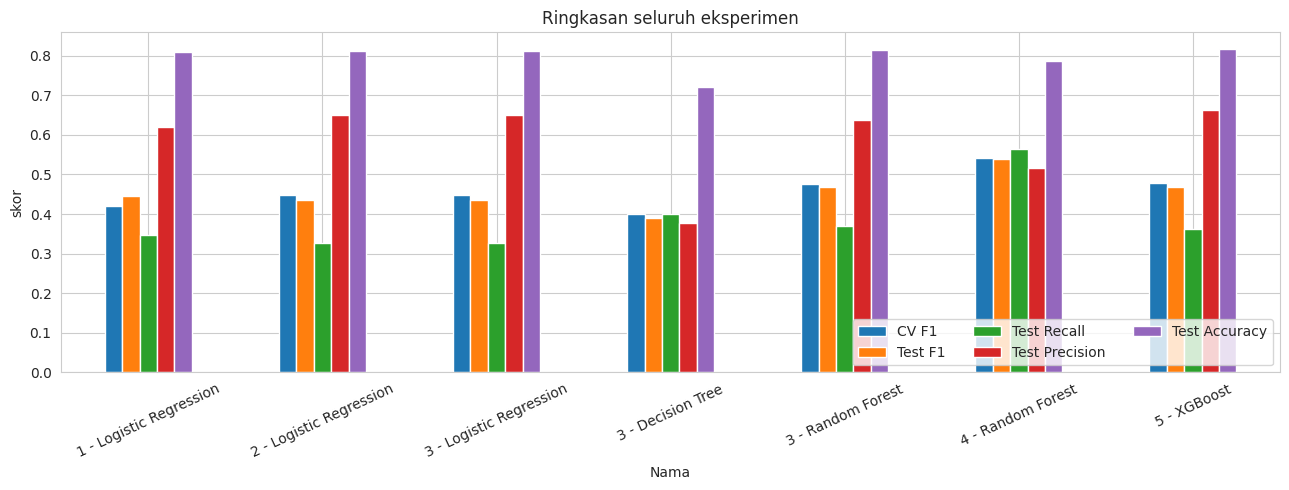

In [ ]:
plot_df = summary.copy()
plot_df["Nama"] = plot_df["Experiment"] + " - " + plot_df["Model"]
plot_df.set_index("Nama")[["CV F1", "Test F1", "Test Recall", "Test Precision", "Test Accuracy"]].plot.bar(figsize=(13, 5), rot=25)
plt.title("Ringkasan seluruh eksperimen"); plt.ylabel("skor"); plt.legend(loc="lower right", ncol=3)
plt.tight_layout(); plt.show()

### Evaluasi detail model final

               precision    recall  f1-score   support

Tidak default     0.8727    0.8498    0.8611      4673
      Default     0.5159    0.5637    0.5387      1327

     accuracy                         0.7865      6000
    macro avg     0.6943    0.7067    0.6999      6000
 weighted avg     0.7938    0.7865    0.7898      6000



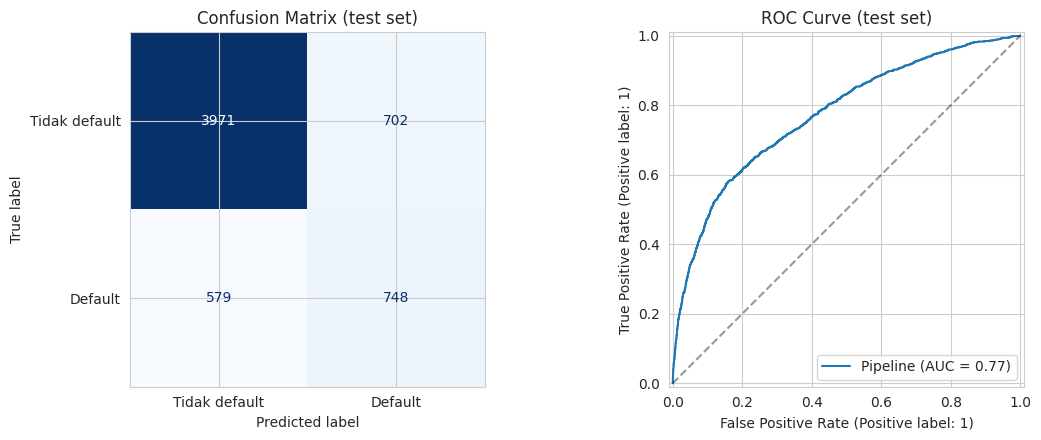

In [ ]:
final_model = fitted[final_label]
pred_f = final_model.predict(X_test)
print(classification_report(y_test, pred_f, target_names=["Tidak default", "Default"], digits=4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_f), display_labels=["Tidak default", "Default"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Confusion Matrix (test set)")
RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--", alpha=0.4); ax[1].set_title("ROC Curve (test set)")
plt.tight_layout(); plt.show()

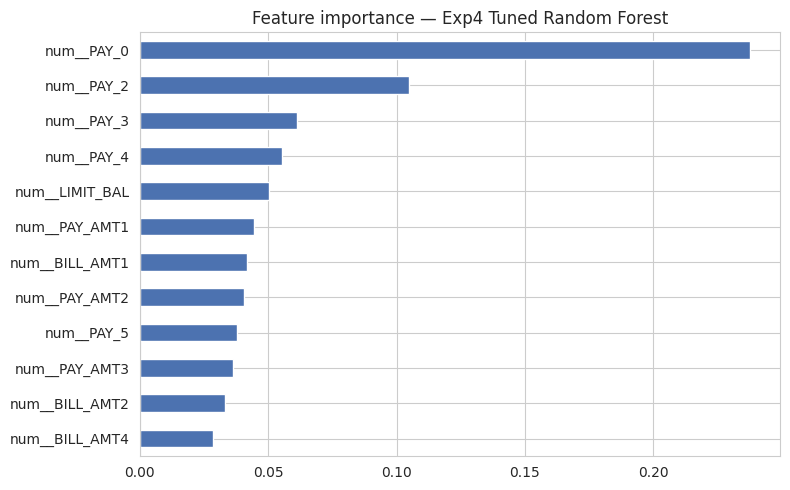

In [ ]:
clf = final_model.named_steps["clf"]
names = final_model.named_steps["prep"].get_feature_names_out()
if hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=names); ttl = "Feature importance"
else:
    imp = pd.Series(np.abs(clf.coef_[0]), index=names); ttl = "Besar koefisien (|coef|, fitur terstandarisasi)"
imp.sort_values().tail(12).plot.barh(figsize=(8, 5), color="#4C72B0")
plt.title(f"{ttl} — {final_label}"); plt.tight_layout(); plt.show()